# Explore GRS images

## Load python libraries

In [1]:

import glob
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # activate the rio accessor

#import cartopy
import cartopy.crs as ccrs
#import cartopy.feature as cfeature
#import locale
#locale.setlocale(locale.LC_ALL, 'en_US.utf8')
import matplotlib.pyplot as plt
import matplotlib as mpl
#mpl.use('TkAgg')
import hvplot.xarray

import holoviews as hv
import holoviews.operation.datashader as hd
from holoviews import opts
hv.extension('bokeh')
import datashader as ds
from datashader import transfer_functions as tf 
import colorcet as cc
import panel as pn
import panel.widgets as pnw
#import ipywidgets as widgets

import pyproj as ppj
import rasterio
from affine import Affine
from shapely.geometry import box,Point, mapping
from shapely.ops import transform


import grstbx
from grstbx import visual

u = grstbx.utils
opj = os.path.join


## Set Dask local cluster

In [2]:
import dask.distributed
cluster = dask.distributed.LocalCluster()
client = dask.distributed.Client(cluster)
cluster.dashboard_link

'http://127.0.0.1:8787/status'

## Set images to play with

In [3]:

tile='31TGM'
select =grstbx.select_files()
# if you need to change the root path
select.root='/home/harmel/Dropbox/satellite/S2'
select.root='/media/harmel/TOSHIBA EXT/data/satellite'
select.list_tile(tile=tile,product='S2_L2B')
files = select.list_file_path(('2021-08','2021-12-01'))

In [4]:
files

array(['/media/harmel/TOSHIBA EXT/data/satellite/S2_L2B/31TGM/2021/08/02/S2B_MSIl2Bgpt_20210802T102559_N0301_R108_T31TGM_20210802T124113_cc073_v15.nc',
       '/media/harmel/TOSHIBA EXT/data/satellite/S2_L2B/31TGM/2021/08/05/S2B_MSIl2Bgpt_20210805T103629_N0301_R008_T31TGM_20210805T114243_cc091_v15.nc',
       '/media/harmel/TOSHIBA EXT/data/satellite/S2_L2B/31TGM/2021/08/07/S2A_MSIl2Bgpt_20210807T103031_N0301_R108_T31TGM_20210807T130730_cc099_v15.nc',
       '/media/harmel/TOSHIBA EXT/data/satellite/S2_L2B/31TGM/2021/08/10/S2A_MSIl2Bgpt_20210810T104031_N0301_R008_T31TGM_20210810T132749_cc003_v15.nc',
       '/media/harmel/TOSHIBA EXT/data/satellite/S2_L2B/31TGM/2021/08/12/S2B_MSIl2Bgpt_20210812T102559_N0301_R108_T31TGM_20210812T124236_cc000_v15.nc',
       '/media/harmel/TOSHIBA EXT/data/satellite/S2_L2B/31TGM/2021/08/15/S2B_MSIl2Bgpt_20210815T103629_N0301_R008_T31TGM_20210815T124403_cc016_v15.nc',
       '/media/harmel/TOSHIBA EXT/data/satellite/S2_L2B/31TGM/2021/08/17/S2A_MSIl2Bgpt_2

## Load and subset image series

In [5]:
# central coordinate
lon, lat = 6.56, 46.384
# size in meter of the rectangle of interest
width, height = 35000, 21000

ust = grstbx.utils.spatiotemp()
box = ust.wktbox(lon,lat, width=width, height=height, ellps='WGS84')
bbox = gpd.GeoSeries.from_wkt([box]).set_crs(epsg=4326)

# generate datacube
dc = grstbx.l2grs(files)

In [6]:
dc.load(subset=bbox,reshape=False)#,reproject=True)

## Check data/metadata

In [7]:
#dc.Rrs

## Check flags and masking

In [8]:
pn.widgets.DataFrame(pd.DataFrame.from_dict(dc.datacube.metadata.attrs,orient='index'),height=300)


DataFrame(height=300, value=              ...)

## Check flags and masking

In [9]:
masking_ = grstbx.masking(dc.datacube)
masking_.print_info()

,description,value,bit
name,,,
nodata,nodata in input image,1,0
negative,negative values in visible,2,1
ndwi,based on ndwi vis nir TOA based on bands B3 an...,4,2
ndwi_swir,based on ndwi nir swir TOA based on bandsB8A a...,8,3
high_nir,"high radiance in the nir band (e.g., cloud, sn...",16,4
hicld,high cloud as observed from cirrus band; condi...,32,5
moderate_cloud_risk_O2band,moderate risk of bright cloud as observed from...,64,6
high_cloud_risk_O2band,high risk of bright cloud as observed from O2 ...,128,7
L1_opaque_clouds,flag from L1 image,256,8


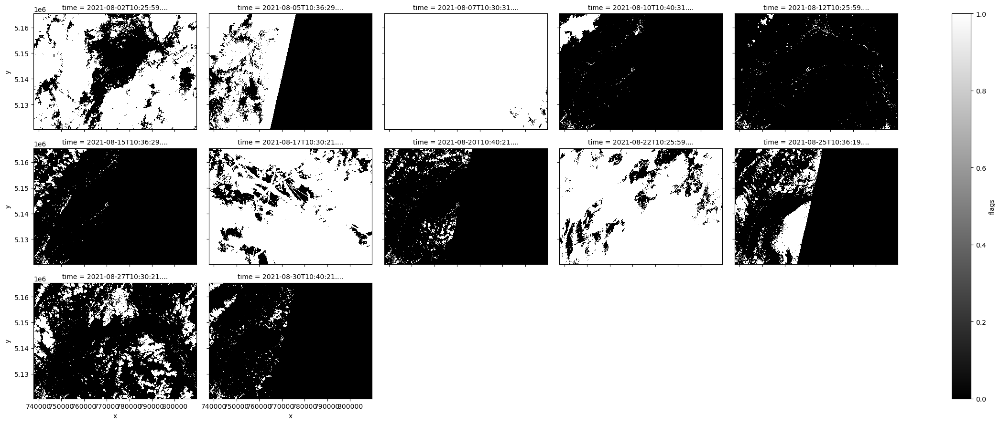

In [10]:
mask = (masking_.get_mask(high_nir=True) | masking_.get_mask(hicld=True)) 
aspect=1.5
mask.plot.imshow(col='time',col_wrap=5,vmin=0,cmap=plt.cm.binary_r,aspect=aspect)

## Mask datacube
Mask pixels from chosen flags and remove empty dates

In [11]:
masked = dc.datacube.where(mask==0).dropna('time','all')
masked

<xarray.Dataset>
Dimensions:               (time: 12, y: 2256, x: 3592)
Coordinates:
    spatial_ref           int64 0
  * x                     (x) float64 7.378e+05 7.378e+05 ... 8.096e+05
  * y                     (y) float64 5.165e+06 5.165e+06 ... 5.12e+06 5.12e+06
  * time                  (time) datetime64[ns] 2021-08-02T10:25:59.024000 .....
Data variables: (12/14)
    metadata              (time, y, x) float64 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    flags                 (time, y, x) float64 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    MCI                   (time, y, x) float32 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    MCI_slope             (time, y, x) float32 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    chl_git2008_sunglint  (time, y, x) float32 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    chl_git2008           (time, y, x) float32 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    ...                    ...
    NDCI                  (time, y, x) float32 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    spm                   (time, y, x) float32 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    turb                  (time, y, x) float32 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    Kd_par                (time, y, x) float32 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    acdom                 (time, y, x) float32 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
    crs                   (time, y, x) float64 dask.array<chunksize=(1, 319, 155), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.4
    TileSize:          256:256
    product_type:      org.esa.s2tbx.processor.mci.S2MciOp
    metadata_profile:  beam
    metadata_version:  0.5
    start_date:        02-AUG-2021 10:25:59.024000
    stop_date:         02-AUG-2021 10:25:59.024000

In [24]:
del v
v=visual.view_param(masked)#,reproject=True)

In [ ]:
v.visu()

## If you want to clip the raster image from the selected area of interest (last polygon drawn); otherwise skip this part.

In [29]:
v.aoi_stream.element.geom()

In [33]:
from shapely.geometry import Polygon
geom = v.aoi_stream.data
# if geom empty set it up by hand
geom ={'xs': [np.array([720070.41876771, 726306.6636905 , 725155.35693552, 719974.47653812,
         720070.41876771])],
 'ys': [np.array([5851780.8436506 , 5851780.8436506 , 5848806.63453357,
         5848902.57676315, 5851780.8436506 ])]}

ys,xs=geom['ys'][-1],geom['xs'][-1]
polygon_geom = Polygon(zip(xs, ys))
polygon = gpd.GeoDataFrame(index=[0], crs=3857, geometry=[polygon_geom]) 
geom_ = polygon.to_crs(3857)#Rrs_masked.rio.crs) #4326)#32631)#4326)
geom_.to_crs(4326).bounds

# if you want to subset within the box (defined from the polygon) uncomment the following lines
#minx, miny, maxx, maxy = geom_.bounds.values[0]
#Rrs_masked.sel(x=slice(minx, maxx), y=slice(maxy, miny))

,minx,miny,maxx,maxy
0,6.467641,46.425541,6.524524,46.443954


In [34]:
geom_.to_crs(masked.rio.crs)

,geometry
0,"POLYGON ((766410.050 5149223.101, 770712.673 5..."


In [35]:
#set geom coordinate system
geom_ = geom_.to_crs(masked.rio.crs)
clipped = masked.rio.clip(geom_.geometry.values)

In [37]:
h=visual.view_param(clipped,reproject=True)

In [ ]:
h.visu()

In [91]:
stacked = clipped.stack(gridcell=["y", "x"]).dropna('gridcell','all')

In [92]:
stacked = stacked.as_numpy()

In [96]:

def compute_stats(xarr, stat_coord='gridcell',limits=[-np.inf,np.inf],dropna=True,time_coord='time'):
    xarr = xarr.where((xarr>limits[0])&(xarr<limits[1]))
    stats = xr.Dataset({'median':xarr.median(stat_coord)})
    stats['q25'] = xarr.quantile(0.25,dim=stat_coord)
    stats['q75'] = xarr.quantile(0.75,dim=stat_coord)
    stats['min'] = xarr.min(stat_coord)
    stats['max'] = xarr.max(stat_coord)
    stats['mean'] = xarr.mean(stat_coord)
    stats['std'] = xarr.std(stat_coord)
    stats['pix_num'] = xarr.count(stat_coord)
    if dropna:
        return stats.dropna(time_coord)
    else:
        return stats


Compute statitics for a given parameter, you can set the lower and upper limits of the valid data range:

In [97]:
param='chl_OC2E'
stats = compute_stats(stacked[param],limits=[0.01,1000])

/home/harmel/anaconda3/envs/grstbx/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1583: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/home/harmel/anaconda3/envs/grstbx/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Check the outcomes before plotting

In [83]:
df = stats.to_dataframe()#.reset_index()
pn.widgets.DataFrame(df,height=300,width=1200)

DataFrame(height=300, sizing_mode='fixed', value=              ..., width=1200)

Plot time series

In [99]:
import pandas_bokeh
df = stats.to_dataframe()
df[['q25','median','q75']].plot_bokeh(ylabel=param,figsize=(1000, 500),plot_data_points=True,colormap=["grey", "black","grey"],rangetool=True)

Column(id='7922', ...)

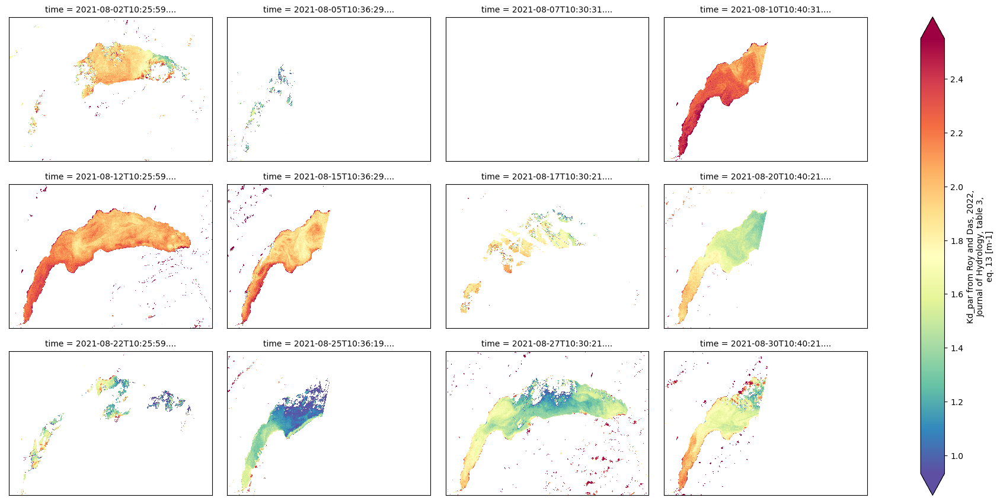

In [15]:
param="Kd_par"
fig = masked[param].plot.imshow(col='time', cmap=plt.cm.Spectral_r,col_wrap=4,robust=True,aspect=aspect)
for ax in fig.axs.flat:
    ax.set(xticks=[], yticks=[])
    ax.set_ylabel('')
    ax.set_xlabel('')
fig


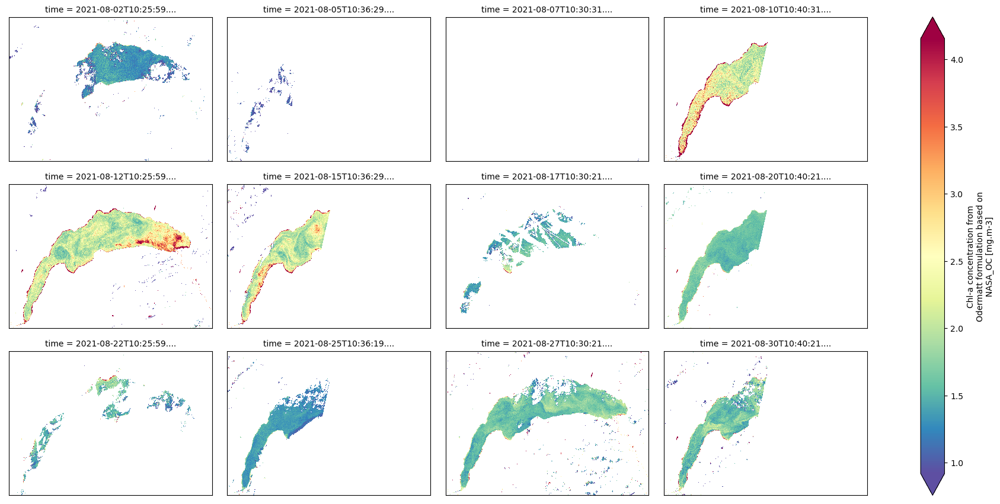

In [16]:
param="chl_OC2E"
fig = masked[param].plot.imshow(col='time', cmap=plt.cm.Spectral_r,col_wrap=4,robust=True,aspect=aspect)
for ax in fig.axs.flat:
    ax.set(xticks=[], yticks=[])
    ax.set_ylabel('')
    ax.set_xlabel('')
fig

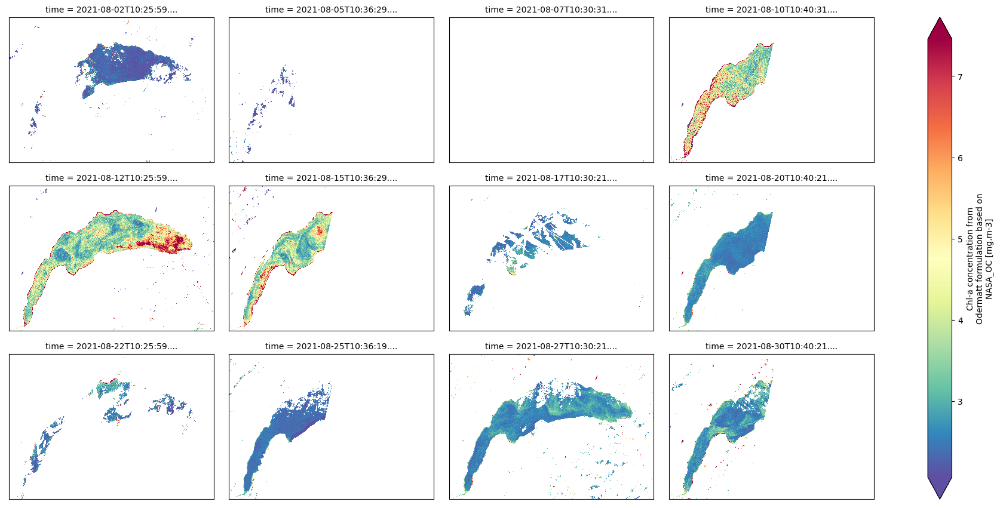

In [17]:
param="chl_OC2_odermatt"
fig = masked[param].plot.imshow(col='time', cmap=plt.cm.Spectral_r,col_wrap=4,robust=True,aspect=aspect)
for ax in fig.axs.flat:
    ax.set(xticks=[], yticks=[])
    ax.set_ylabel('')
    ax.set_xlabel('')
fig

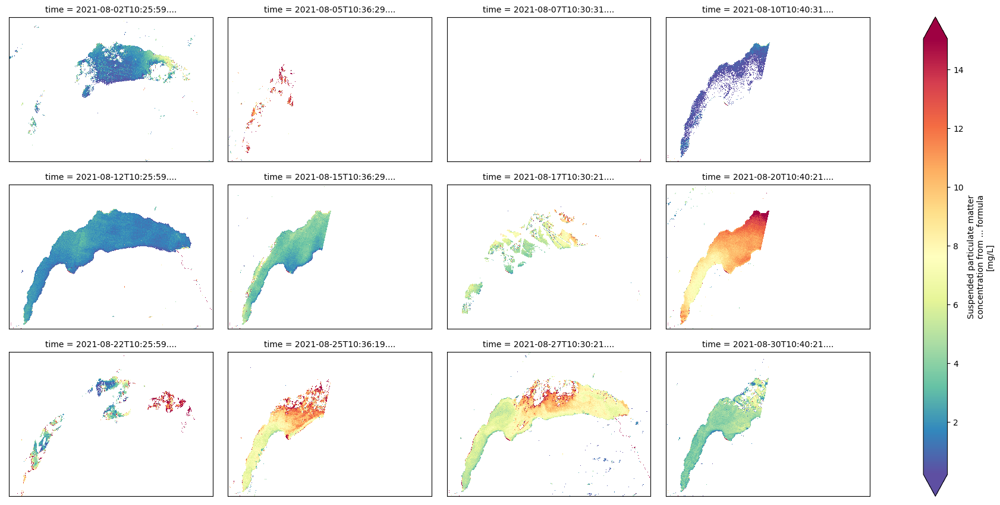

In [18]:
param="spm"
fig = masked[param].plot.imshow(col='time', cmap=plt.cm.Spectral_r,col_wrap=4,robust=True,aspect=aspect)
for ax in fig.axs.flat:
    ax.set(xticks=[], yticks=[])
    ax.set_ylabel('')
    ax.set_xlabel('')
fig

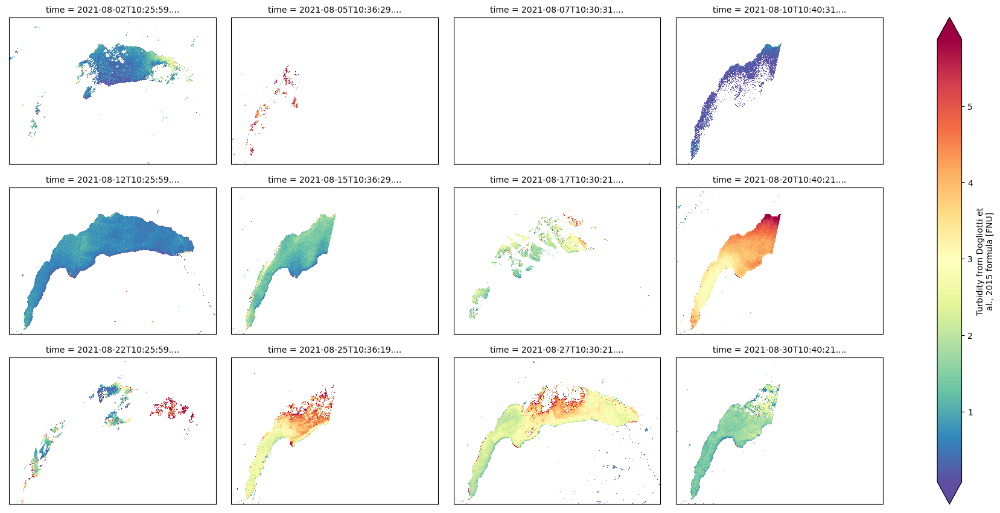

In [19]:
param="turb"
fig = masked[param].plot.imshow(col='time', cmap=plt.cm.Spectral_r,col_wrap=4,robust=True,aspect=aspect)
for ax in fig.axs.flat:
    ax.set(xticks=[], yticks=[])
    ax.set_ylabel('')
    ax.set_xlabel('')
fig

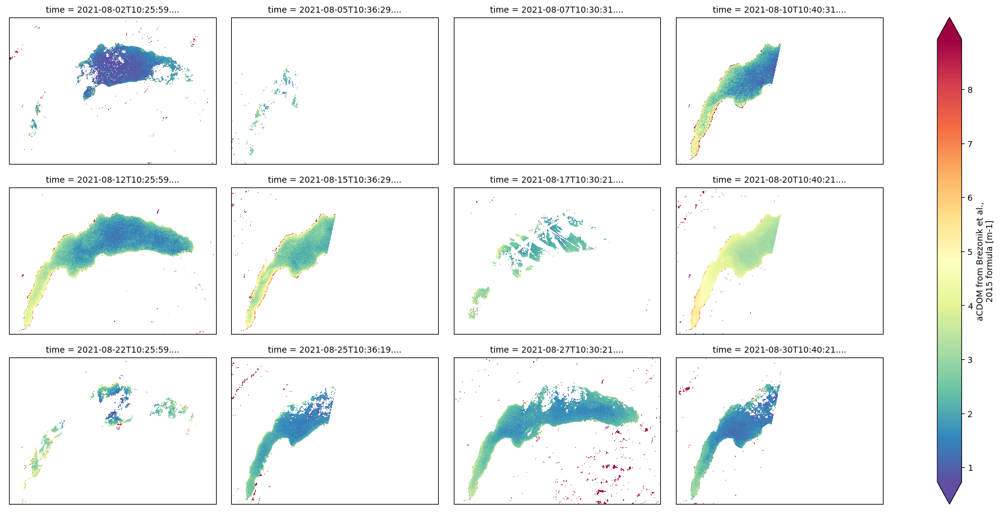

In [20]:
param='acdom'
fig = masked[param].plot.imshow(col='time', cmap=plt.cm.Spectral_r,col_wrap=4,robust=True,aspect=aspect)
for ax in fig.axs.flat:
    ax.set(xticks=[], yticks=[])
    ax.set_ylabel('')
    ax.set_xlabel('')
fig

In [ ]:
plt.subplots()
stats.groupby(col='time',col_wrap=4)
plt.show()

In [ ]:
stacked.plot(col='time',hue='gridcell',c='k',alpha=0.1,lw=1)

In [ ]:
plt.figure()
for name,group in stacked.isel(time=1).groupby('gridcell'):
    g_=group
    plt.plot(g_.wl,g_.values,c='k',alpha=0.1,lw=1)#plot(x='wl')
plt.show()

In [ ]:
group.squeeze().values

In [ ]:
from bokeh.tile_providers import STAMEN_TONER
from bokeh.models import BoxSelectTool, BoxZoomTool, LassoSelectTool
from holoviews.streams import PointDraw, PolyEdit, BoxEdit, PolyDraw, FreehandDraw
import geoviews as gv

In [ ]:
path_annotator = hv.annotate.instance()
tiles = gv.tile_sources.StamenTonerBackground.opts(width=600, height=570, global_extent=True,active_tools=['wheel_zoom']) 

sample_box = hv.Bounds((50, 32.25, 90.85, 45))

polys = gv.Polygons([])


#box_stream = BoxEdit(source=polys, num_objects=3)
poly_stream = PolyDraw(source=polys, show_vertices=True, shared=True)
poly_edit = PolyEdit(source=polys, vertex_style={'color': 'red'})
(tiles * polys).opts(
    opts.Polygons(fill_alpha=0.5, line_color='black', selection_fill_color='red',tools=['poly_edit']))


In [ ]:
def bbox(poly):
    "Convert the polygon returned by the BoxEdit stream into a bounding box tuple"
    xs,ys = poly.array().T
    return (xs[0], ys[0], xs[2], ys[2])

if poly_stream.element:
    polygons = poly_stream.element.split()
    bboxes = [bbox(p) for p in polygons]
    print(bboxes)


In [ ]:
poly_stream.element.geom().opts()

In [ ]:
points = hv.Points([(0.0, 0.0), (1.0, 1.0), (200000.0, 2000000.0)]).opts(size=10, min_height=500)

annotator = hv.annotate.instance()
layout = annotator(hv.element.tiles.Wikipedia() * points, annotations=['Label'], name="Point Annotations")
layout

In [27]:
import panel as pn
import param
import geoviews as gv
import holoviews as hv
import pandas as pd
import geopandas as gpd
from datashader.utils import lnglat_to_meters
from shapely.geometry import Point, Polygon
from cartopy import crs

gv.extension('bokeh',logo=False)
pn.extension()


class Inputs(param.Parameterized):
    
    input_file = param.FileSelector(path='.\sample_data\*.csv', doc='A .csv file selector for input data')
    x_field    = param.Selector(doc='A field selector for longitude')
    y_field    = param.Selector(doc='A field selector for latitude')
    id_field   = param.Selector(doc='A field selector for the identifier')
    data       = None
    
    @param.depends('input_file', watch=True)
    def update_inputs(self):
        
        df                          = pd.read_csv(self.input_file)
        numeric_cols                = list(df.select_dtypes(include=['float64']).columns)
        columns                     = [x for i,x in enumerate(df.columns) if x !='Unnamed: 0']
        self.param.x_field.objects  = numeric_cols
        self.x_field                = numeric_cols[0]
        self.param.y_field.objects  = numeric_cols
        self.x_field                = numeric_cols[0]
        self.param.id_field.objects = columns
        self.id_field               = columns[0]
        self.data                   = df

        
class Mapview(param.Parameterized):
    
    tiles         = gv.tile_sources.CartoEco()
    aoi_polygons  = gv.Polygons([], crs=crs.GOOGLE_MERCATOR)
    aoi_colours   = ['red','blue','green','orange','purple']
    aoi_stream    = hv.streams.PolyDraw(source=aoi_polygons, num_objects=5,styles={'fill_color': aoi_colours})
    template_df   = pd.DataFrame({'lng': [], 'lat': []}, columns=['lng', 'lat'])
    dfstream      = hv.streams.Buffer(template_df, index=False, length=10000, following=False)
    points        = hv.DynamicMap(gv.Points, streams=[dfstream])
    map_layout    = tiles * aoi_polygons * points
    
    def show_map(self):
        # set style options on map_layout
        self.map_layout.opts(
            # the ratio of WMTS height:width must be eqaul to the data_aspect value (0.5)
            # or the map will stretch/skew
            gv.opts.WMTS(global_extent=True,width=1200,height=600,show_grid=False,xaxis=None,yaxis=None),
            gv.opts.Polygons(fill_alpha=0.1),
            gv.opts.Points(size=5, color='green', fill_alpha=0.3, line_alpha=0.4)
        )        
        return self.map_layout.opts(data_aspect=0.5)


    
class Aoi(param.Parameterized):
    aoi = param.String('Name')
    
    def set_aoi_textbox_style(self, row, color='rgba(0,0,0,0)'):
        row.background = color
        row.objects[0][0].value = ''
        row.objects[0][1].name = ''
        row.objects[0].width = 145
    
    
class Dashboard(param.Parameterized):
    
    input1    = Inputs()
    input2    = Inputs()
    input3    = Inputs()
    input4    = Inputs()
    input5    = Inputs()
    mapview   = Mapview()
    
    run_button = param.Action(lambda x: x.param.trigger('run_button'), label='Run')

    # create colour-coded text input boxes to allow the user to optionally provide names for
    # the AOIs drawn on the map
    
    aois = []

    red = Aoi()
    red_label = pn.Row(red, width=150)
    red.set_aoi_textbox_style(red_label, 'rgba(255,0,0,0.4)')
    aois.append(red_label)

    blue = Aoi()
    blue_label = pn.Row(blue, width=150)
    blue.set_aoi_textbox_style(blue_label, 'rgba(0,0,255,0.4)')
    aois.append(blue_label)

    green = Aoi()
    green_label = pn.Row(green, width=150)
    green.set_aoi_textbox_style(green_label, 'rgba(0,255,0,0.4)')
    aois.append(green_label)

    orange = Aoi()
    orange_label = pn.Row(orange, width=150)
    orange.set_aoi_textbox_style(orange_label, 'rgba(255,165,0,0.4)')
    aois.append(orange_label)

    purple = Aoi()
    purple_label = pn.Row(purple, width=150)
    purple.set_aoi_textbox_style(purple_label, 'rgba(150,0,150,0.4)')
    aois.append(purple_label)

    def show_aoi_gui(self):
        
        return pn.Row(pn.Spacer(width=5),
                      self.red_label,pn.Spacer(width=3),
                      self.blue_label,pn.Spacer(width=3),
                      self.green_label,pn.Spacer(width=3),
                      self.orange_label,pn.Spacer(width=3),
                      self.purple_label,pn.Spacer(width=3))
    
    
    def project_to_meters(self, df, x, y):
        """While Geoviews will automatically project coordinates in degrees into meters to
    match the coordinate system of the WMTS object, the Geopandas.GeoDataFrame.intersects()
    method employed in the run_analysis() function requires the point coordinates to have
    the same coordinates as the polygon geometries. Therefor the point coordinates must be projected
    to web mercator (epsg:3857)"""
        try:
            df.loc[:,'x_meters'], df.loc[:,'y_meters'] = lnglat_to_meters(df[x],df[y])
            geometry = [Point(xy) for xy in zip(df.x_meters, df.y_meters)]
            web_merc = {'init': 'epsg:3857'}
            return gpd.GeoDataFrame(df, crs=web_merc, geometry=geometry)
        except:
            print("""Could not project specified coordinate fields to meters. Make sure the X Field and Y Field 
                  values have been set correctly.\n""")


    @param.depends('run_button')
    def run_analysis(self):
        try:
            # clear previous results
            self.mapview.dfstream.clear()

            # Convert each input into a GeoDataFrame and project coordinates to meters
            datasets  = []
            id_fields = []
            for i in [self.input1, self.input2, self.input3, self.input4, self.input5]:
                if isinstance(i.data, pd.core.frame.DataFrame):
                    gdf = self.project_to_meters(i.data, i.x_field, i.y_field)
                    datasets.append(gdf)
                    id_fields.append(i.id_field)
            
            if len(datasets)>0:
                # Convert polygons drawn on the map into Shapely polygon geometries
                poly_data = d.mapview.aoi_stream.data
                polygons = []
                for r in range(len(poly_data['xs'])):
                    xs = poly_data['xs'][r]
                    ys = poly_data['ys'][r]
                    vertices = list(zip(xs,ys))
                    polygons.append(Polygon(vertices))
                
                # Do intersections of each polygon on each GeoDataFrame & send results to the map
                df_all_polys = pd.DataFrame()
                df_final = pd.DataFrame()
                poly_labels = []
                
                for i in range(len(datasets)):
                    for p in polygons:
                        # if the user does not specify a name for the aoi, use 
                        # the colour as the name
                        if (self.aois[polygons.index(p)].objects[0][1].value == 'Name'):
                            poly_label = self.mapview.aoi_colours[polygons.index(p)] + '_aoi'
                        # else use the name provided by the user
                        else:
                            poly_label = self.aois[polygons.index(p)].objects[0][1].value + '_user_provided'
                        poly_labels.append(poly_label)
                        datasets[i][poly_label] = datasets[i].intersects(p)
                        selected = datasets[i].loc[datasets[i][poly_label]==True].drop(columns='geometry')
                        self.mapview.dfstream.send(pd.DataFrame(selected[['lng','lat']]))                   
                        selected.rename(columns={id_fields[i]:'identifier'},inplace=True)
                        df_all_polys = pd.concat([df_all_polys,selected[['identifier',poly_label]]],axis=0,ignore_index=True)

                for ident in pd.unique(df_all_polys['identifier']):
                    dfx = df_all_polys.loc[df_all_polys['identifier']==ident]
                    poly_values = {'identifier':[ident]}
                    for label in poly_labels:
                        # returns true if any of the values are true
                        poly_values[label] = [dfx[label].any()]
                    df_ident = pd.DataFrame.from_dict(poly_values)
                    df_final = pd.concat([df_final, df_ident],axis=0)

                def summarize_polys(row):
                    cols = list(row.axes[0])
                    s = []
                    for c in cols:
                        if '_aoi' in c:
                            if row.values[cols.index(c)]:
                                s.append(c.split('_aoi')[0])
                        if '_user_provided' in c:
                            if row.values[cols.index(c)]:
                                s.append(c.split('_user_provided')[0])
                    return ','.join(s)

                summary = df_final.copy()
                
                try:
                    summary['Found_In'] = summary.apply(lambda row: summarize_polys(row),axis=1)
                    # remove the '_user_provided' flag from column names where it exists
                    for col in summary.columns.to_list():
                        if '_user_provided' in col:
                            summary.rename(columns={col : col.split('_user_provided')[0]}, inplace=True)
                            
                    return pn.widgets.DataFrame(summary, disabled=True, fit_columns=True, width=700)
                
                except:
                    print('There was an error creating the final output summary table.\n')
            
            else:
                print('You must select at least one input dataset.\n')
        
        except:
            print('Something went wrong in the run_analysis() function.\n')
            # show the message in the Table View tab of the dashboard
            return('Something went wrong in the run_analysis() function.')

       
    def view(self):
        
        desc = """This is a demonstration dashboard with incomplete functionality. Its purpose
        is to sit here and look pretty. We can put graphics and stuff in here to
        make it look all fancy."""

        logo = '.\images\logo_panel_stacked_s.png'
        
        button_desc = """The <i>Run</i> button will execute the spatial intersection and generate
        a table of identifiers found within each polygon and in multiple polygons.<br><br>
        Push the <i>Run</i> button after configuring all inputs and drawing polygons on the map."""

        return pn.Row(
                pn.Column(
                    '## Description',
                    desc,logo),
                pn.Column(
                    '### Configure Inputs',
                    pn.Tabs(
                        ('Input 1',self.input1),
                        ('Input 2',self.input2),
                        ('Input 3',self.input3),
                        ('Input 4',self.input4),
                        ('Input 5',self.input5)),
                    button_desc,
                    self.param['run_button']),
                pn.Column(pn.Tabs(
                        ('Map View', self.mapview.show_map),
                        ('Results Table', self.run_analysis)),
                        pn.Column(
                            pn.Row(pn.Spacer(width=5),'Optionally provide names for drawn AOIs:'),
                            self.show_aoi_gui
                        )))

d = Dashboard()
d.view().show()

You must select at least one input dataset.

Launching server at http://localhost:35891


In [ ]:


np.random.seed(42)
polys = hv.Polygons([hv.Box(*i, spec=np.random.rand()/3)
                     for i in np.random.rand(10, 2)])
ovals = hv.Polygons([hv.Ellipse(*i, spec=np.random.rand()/3)
                     for i in np.random.rand(10, 2)])
poly_edit = PolyEdit(source=polys, vertex_style={'color': 'red'}, shared=True)
poly_edit2 = PolyEdit(source=ovals, shared=True)

(polys * ovals).opts(
    opts.Polygons(active_tools=['poly_edit'], fill_alpha=0.4, height=400, width=400))



In [ ]:
polys = hv.Polygons([
    {('x', 'y'): [[0,0],[0,1],[1,1]], 'name':'foo'},
    {('x', 'y'): [[0,2],[2,2],[2,3]], 'name':'bar'}
], vdims=['name'])

poly_select = hv.streams.Selection1D()
dmap = hv.DynamicMap(lambda index: polys.iloc[index] if index else polys, streams=[poly_select])

poly_edit = hv.streams.PolyEdit(
    source=dmap, 
    vertex_style={'color': 'blue', 'size': 4}
)
poly_draw = hv.streams.PolyDraw(
    source=dmap, 
    drag=False, 
    show_vertices=True, 
    vertex_style={'color': 'blue', 'size': 4}
)

dmap.opts(hv.opts.Polygons(tools=['tap', 'hover']))


In [ ]:
point_annotate = hv.annotate.instance()
points = hv.Points([(500000, 500000), (1000000, 1000000)]).opts(size=10, color='red', line_color='black')
point_layout = point_annotate(points, annotations=['Label'])

poly_annotate = hv.annotate.instance()
poly_layout = poly_annotate(hv.Polygons([]), annotations=['Label'])

hv.annotate.compose(hv.element.tiles.OSM(), point_layout, poly_layout)


In [ ]:
path = hv.Path([hv.Box(0, 0, 1), hv.Ellipse(1, 1, 1)])

path_annotator = hv.annotate.instance()

path_annotator(path.opts(width=800, height=400, responsive=False), annotations=['Label'], vertex_annotations=['Value'])

In [ ]:
Rrs_masked.isel(wl=2).plot(col='time',col_wrap=5,vmin=0,vmax=0.03, robust=True,cmap=plt.cm.Spectral_r,aspect=1.6)

## **Check spectral datacube** (i.e., Remote Sensing Reflectance, R<sub>rs</sub>, sr<sup>-1</sup>)

To quickly check your data visually, you can use the *visual* module of *grstbx*

In [ ]:
visual.image_viewer().Rrs_date(Rrs_masked)

## **Fast checking of the RGB images**

In [ ]:
bands=[4,2,1]
bands=[3,2,1]
Rrs_masked.isel(wl=bands).plot.imshow(col='time', col_wrap=4,robust=True,aspect=aspect)


In [ ]:
import datashader as ds
from datashader import transfer_functions as tf 
from colorcet import palette


shaded = []
for name, raster in Rrs_masked.isel(wl=2).groupby('time'):
    img = tf.shade(raster.squeeze(),cmap=cc.kbc)
    img.name = str(name)
    shaded.append(img)

imgs = tf.Images(*shaded)
imgs.num_cols = 3
imgs

In [ ]:
from holoviews import opts

opts.defaults(
    opts.GridSpace(shared_xaxis=True, shared_yaxis=True),
    opts.Image(cmap='binary_r', width=800, height=700),
    opts.Labels(text_color='white', text_font_size='8pt', text_align='left', text_baseline='bottom'),
    opts.Path(color='white'),
    opts.Spread(width=900),
    opts.Overlay(show_legend=True))
# set the parameter for spectra extraction
hv.extension('bokeh')
pn.extension()

raster = Rrs_masked#.isel(time=-1,drop=True)
ds = hv.Dataset(raster.persist())
im= ds.to(hv.Image, ['x', 'y'], dynamic=True).opts(cmap= 'RdBu_r',colorbar=True)#.hist(bin_range=(0,0.02) ) 
widget = pn.widgets.RangeSlider(start=0, end=0.1,step=0.001)

jscode = """
    color_mapper.low = cb_obj.value[0];
    color_mapper.high = cb_obj.value[1];
"""
link = widget.jslink(im, code={'value': jscode})
pn.Column(widget, im)

In [ ]:

param = 'Rrs'
third_dim = 'wl'
raster = Rrs_masked.isel(time=1,drop=True)
wl= raster.wl.data
Nwl = len(wl)
ds = hv.Dataset(raster.persist())
im= ds.to(hv.Image, ['x', 'y'], dynamic=True).opts(cmap= 'RdBu_r',colorbar=True,clim=(0,None)).hist(bin_range=(0,0.02) ) 

polys = hv.Polygons([])
box_stream = hv.streams.BoxEdit(source=polys)
dmap, dmap_std=[],[]

def roi_curves(data,ds=ds):    
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMa






    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMa
    if not data or not any(len(d) for d in data.values()):
        return hv.NdOverlay({0: hv.Curve([],'Wavelength (nm)', 'Rrs')})

    curves,envelope = {},{}
    data = zip(data['x0'], data['x1'], data['y0'], data['y1'])
    for i, (x0, x1, y0, y1) in enumerate(data):
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMa
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMa
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMa
hlines = hv.HoloMa
        selection = ds.select(x=(x0, x1), y=(y0, y1))
        mean = selection.aggregate(third_dim, np.mean).data
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMa
        std = selection.aggregate(third_dim, np.std).data
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMa
        wl = mean.wl

        curves[i]= hv.Curve((wl,mean[param]),'Wavelength (nm)', 'Rrs') 

    return hv.NdOverlay(curves)


# a bit dirty to have two similar function, but holoviews does not like mixing Curve and Spread for the same stream
def roi_spreads(data,ds=ds):    
    if not data or not any(len(d) for d in data.values()):
        return hv.NdOverlay({0: hv.Curve([],'Wavelength (nm)', 'Rrs')})

    curves,envelope = {},{}
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMa
    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMa
    data = zip(data['x0'], data['x1'], data['y0'], data['y1'])
    for i, (x0, x1, y0, y1) in enumerate(data):
        selection = ds.select(x=(x0, x1), y=(y0, y1))
        mean = selection.aggregate(third_dim, np.mean).data
        std = selection.aggregate(third_dim, np.std).data
        wl = mean.wl

        curves[i]=  hv.Spread((wl,mean[param],std[param]),fill_alpha=0.3)

    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    
hlines = hv.HoloMap({wl[i]: hv.VLine(wl[i]) for i in range(Nwl)},third_dim )


In [ ]:

# visualize and play
graphs = ((mean* std *hlines).relabel('Rrs'))
layout = (im * polys +graphs    ).opts(
    opts.Curve(width=600, framewise=True,xlim=(400,1000)), 
    opts.Polygons(fill_alpha=0.2, color='green',line_color='black'), 
    opts.VLine(color='black')).cols(2)
layout 

# Check surface rugosity via sunglint BRDF

In [ ]:

raster = BRDFg#.isel(time=-1,drop=True)
ds = hv.Dataset(raster.persist())
im= ds.to(hv.Image, ['x', 'y'], dynamic=True).opts(cmap= 'gray',colorbar=True)#.hist(bin_range=(0,0.02) ) 
widget = pn.widgets.RangeSlider(start=0, end=0.01,step=0.0005)

jscode = """
    color_mapper.low = cb_obj.value[0];
    color_mapper.high = cb_obj.value[1];
"""
link = widget.jslink(im, code={'value': jscode})
pn.Column(widget, im)

In [ ]:

shaded = []
for name, raster in BRDFg.groupby('time'):
    img = tf.shade(raster.squeeze(),cmap=cc.gray)
    img.name = str(name)
    shaded.append(img)

imgs = tf.Images(*shaded)
imgs.num_cols = 5
imgs

## Check blue over green ratio for Chl retrieval with OC2 from NASA
$log_{10}(chlor\_a) = a_0 + \sum\limits_{i=1}^4 a_i \left(log_{10}\left(\frac{R_{rs}(\lambda_{blue})}{R_{rs}(\lambda_{green})}\right)\right)^i$

In [ ]:
# NASA OC2 fro MODIS; bands 488, 547 nm
a = [0.2500,-2.4752,1.4061,-2.8233,0.5405]
# NASA OC2 for OCTS; bands 490, 565 nm
a = [0.2236,-1.8296,1.9094,-2.9481,-0.1718]

ratio = np.log10(Rrs_masked.isel(wl=1)/Rrs_masked.isel(wl=2))
logchl=0
for i in range(len(a)):
    logchl+=a[i]*ratio**i
chl = 10**(logchl)
chl.name='chl in mg.m-3 from OC2'

Set range of valid values

In [ ]:
chl = chl.where((chl >= 0) & (chl <= 80))
chl.persist()



In [ ]:
visual.image_viewer().param_date(chl,cmap='bgyw')

In [ ]:
raster = chl

shaded = []
for name, raster in chl.groupby('time'):
    img = tf.shade(raster.squeeze(),cmap=cc.bgyw, span=(0,10),how='log')
    img.name = str(name)
    shaded.append(img)

imgs = tf.Images(*shaded)
imgs.num_cols = 4
imgs

# CDOM retrieval based on Brezonik et al, 2015


In [ ]:
a = [1.872,-0.83]
acdom = np.exp(a[0] + a[1] * np.log(Rrs_masked.isel(wl=1)/Rrs_masked.isel(wl=5)))
acdom.name='CDOM absorption at 440 nm-1'
acdom= acdom.where((acdom >= 0) & (acdom <= 10))
acdom.persist()

In [ ]:
visual.image_viewer().param_date(acdom,cmap='bgyw')

# Total suspended particulate matter (SPM) from Nechad et al., 2010, 2016 formulation
spm in mg/L

In [ ]:
a = [610.94*np.pi, 0.2324/np.pi]
Rrs_ = Rrs_masked.isel(wl=3)
spm = a[0] * Rrs_ / (1 - ( Rrs_/ a[1]))
spm.name='CDOM absorption at 440 nm-1'
spm= spm.where((spm >= 0) & (spm <= 150))
spm.persist()

In [ ]:
visual.image_viewer().param_date(spm,cmap='bgyw')

In [ ]:

shaded = []
for name, raster in dc.Rrs.Rrs.isel(time=-1).groupby('wl'):
    img = tf.shade(raster,cmap=cc.kbc)
    img.name = '{:.2f}'.format(name)+' nm'
    shaded.append(img)

imgs = tf.Images(*shaded)
imgs.num_cols = 3
imgs

In [ ]:
shaded = []
for name, raster in BRDFg.groupby('time'):
    img = tf.shade(raster,cmap=cc.gray, span=(0,0.025),how='log')
    img.name = str(name)
    shaded.append(img)

imgs = tf.Images(*shaded)
imgs.num_cols = 4
imgs

# Play with time series

In [ ]:
raster = spm

param = raster.name
third_dim = 'time'
time= raster.time.data
Ntime = len(time)
ds = hv.Dataset(raster.persist())
im= ds.to(hv.Image, ['x', 'y'], dynamic=True).opts(cmap= 'RdBu_r',colorbar=True,clim=(0,10))#.hist(bin_range=(0,0.02) ) 

polys = hv.Polygons([])
box_stream = hv.streams.BoxEdit(source=polys)
dmap, dmap_std=[],[]

def roi_curves(data,ds=ds):    
    if not data or not any(len(d) for d in data.values()):
        return hv.NdOverlay({0: hv.Curve([],'time', param)})

    curves,envelope = {},{}
    data = zip(data['x0'], data['x1'], data['y0'], data['y1'])
    for i, (x0, x1, y0, y1) in enumerate(data):
        selection = ds.select(x=(x0, x1), y=(y0, y1))
        mean = selection.aggregate(third_dim, np.nanmean).data
        print(mean)
        #std = selection.aggregate(third_dim, np.std).data
        time = mean[third_dim]

        curves[i]= hv.Curve((time,mean[param]),'time', param) 

    return hv.NdOverlay(curves)


# a bit dirty to have two similar function, but holoviews does not like mixing Curve and Spread for the same stream
def roi_spreads(data,ds=ds):    
    if not data or not any(len(d) for d in data.values()):
        return hv.NdOverlay({0: hv.Curve([],'time', param)})

    curves,envelope = {},{}
    data = zip(data['x0'], data['x1'], data['y0'], data['y1'])
    for i, (x0, x1, y0, y1) in enumerate(data):
        selection = ds.select(x=(x0, x1), y=(y0, y1))
        mean = selection.aggregate(third_dim, np.nanmean).data
        std = selection.aggregate(third_dim, np.nanstd).data
        time = mean[third_dim]

        curves[i]=  hv.Spread((time,mean[param],std[param]),fill_alpha=0.3)

    return hv.NdOverlay(curves)

mean=hv.DynamicMap(roi_curves,streams=[box_stream])
std =hv.DynamicMap(roi_spreads, streams=[box_stream])    


In [ ]:
# visualize and play
graphs = ((mean*std ).relabel(param))
layout = (im * polys +graphs    ).opts(
    opts.Curve(width=600, framewise=True), 
    opts.Polygons(fill_alpha=0.2, color='green',line_color='black'), 
    ).cols(2)
layout 

In [ ]:
selection = ds.select(x=(547000,547200), y=(4802000, 4803000))
mean = selection.aggregate(third_dim, np.nanmean).data
std = selection.aggregate(third_dim, np.std).data
time = mean[third_dim]
curves={}
for i in [0,1,2]:
    curves[i]=hv.Curve((time,mean[param]),'time', param)

hv.DynamicMap(hv.NdOverlay(curves)).opts(width=600)